In [ ]:
%matplotlib inline

# Extension Principle and Fuzzy Arithmetic

This is a Jupyter page to help you explore the Extension Principle

Have fun!

Below, I support three binary functions, 

* A+B
* max(A,B)
* min(A,B)

for example,

set[A+B](10) = sup{ min[A(x),B(y)] | x+y == 10}

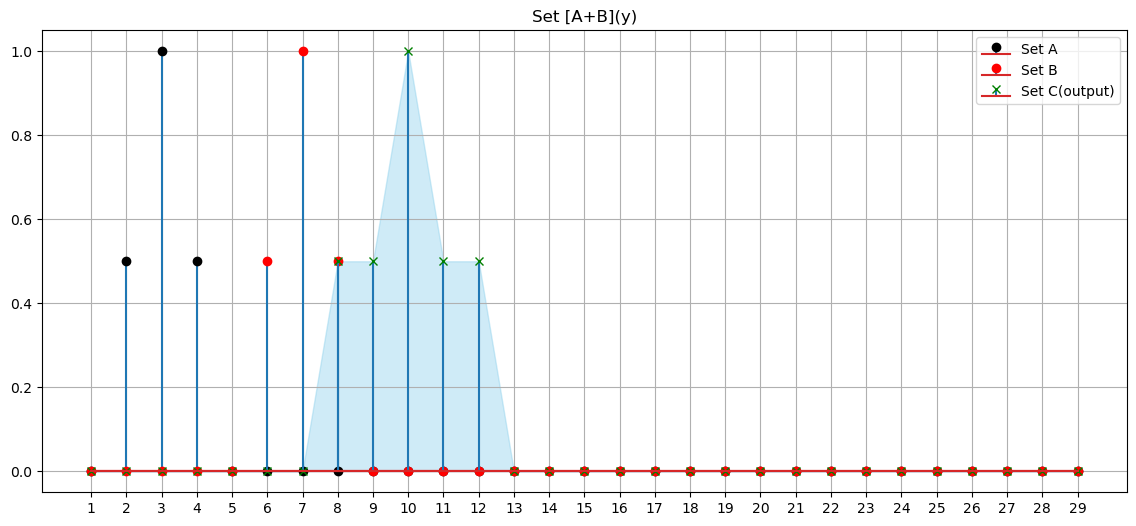

In [10]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm

# our domain
domain = np.asarray( range(1,30,1) )

# fuzzy set 1
# about 3 (The index starts from 0 but the domain value starts from 1.....)
# When we perform ops, we accually selected the ith value in our domain...but not the value i
# 每个loop只是控制index
# 比如说outer loop中的 i==2 实际上我们选的值是 domain[2] == 3 如上面定的domain是从1开始的。。。（这种设定感觉没有必要）
A = np.zeros( domain.size )
A[0] = 0.
A[1] = 0.5
A[2] = 1.0 # This is like: The "2nd"(from 0) element in the domain(starts from 1), which is 3, has a membership value 1....
A[3] = 0.5
A[4] = 0.

# Ohter points are zeros.

# fuzzy set 2
# about 7
B = np.zeros( domain.size )
B[4] = 0.
B[5] = 0.5
B[6] = 1.0
B[7] = 0.5
B[8] = 0.

# output fuzzy set
C = np.zeros( domain.size )

# define the function (choose 1 opration to perform)
def BinaryEpFunction( arg1, arg2, WhichOp ):
    if( WhichOp == 1 ):
        return (arg1 + arg2)       # sum
    elif( WhichOp == 2 ):
        return max( arg1, arg2 )   # max
    elif( WhichOp == 3 ):
        return min( arg1, arg2 )   # min
    elif( WhichOp == 4 ):
        return arg1 * arg2         # mul
    
# which operator do we want to use? 1 == sum, 2 == max, 3 == min, 4 == mul
WhichOp = 1
    
N = domain.size
for i in range(N): # go over each point in our output domain
    for j in range(N): # go over all x
        for k in range(N): # go over all y
            r = BinaryEpFunction( domain[j], domain[k], WhichOp )
            if( r == domain[i] ): # is this one of our points?
                m = min( A[j], B[k] ) # t-norm
                if( m > C[i] ):
                    C[i] = m          # we are taking the sup (C is the output fuzzy set)
                    
# plot it!
fig = plt.figure(figsize=(14, 6))
plt.stem(A,markerfmt='ko',label="Set A") # plt.stem() Draws a vertical line from 0 up to A[i] for each index i. Places a marker black ('o') at the top.
plt.stem(B,markerfmt='ro',label="Set B")
plt.stem(C,markerfmt='gx',label="Set C(output)")
b=range(0,N)
plt.fill_between( b, C, color="skyblue", alpha=0.4) # alpha=0.4 --> 40% opacity (semi-transparent)
xi = list(range(len(domain))) # Domain labels
plt.xticks(xi, domain)
if( WhichOp == 1 ):
    plt.title('Set [A+B](y)')
elif( WhichOp == 2 ):
    plt.title('Set [max(A,B)](y)')
elif( WhichOp == 3 ):
    plt.title('Set [min(A,B)](y)')
elif( WhichOp == 4 ):
    plt.title('Set [A*B](y)')    
plt.grid()
plt.legend()
plt.show()

# Q&A

Think about

* Unary operations
* Does max(A,B) give you what you thought...? What do you think the max(A,B) should be?

# What about an alpha cut approach?

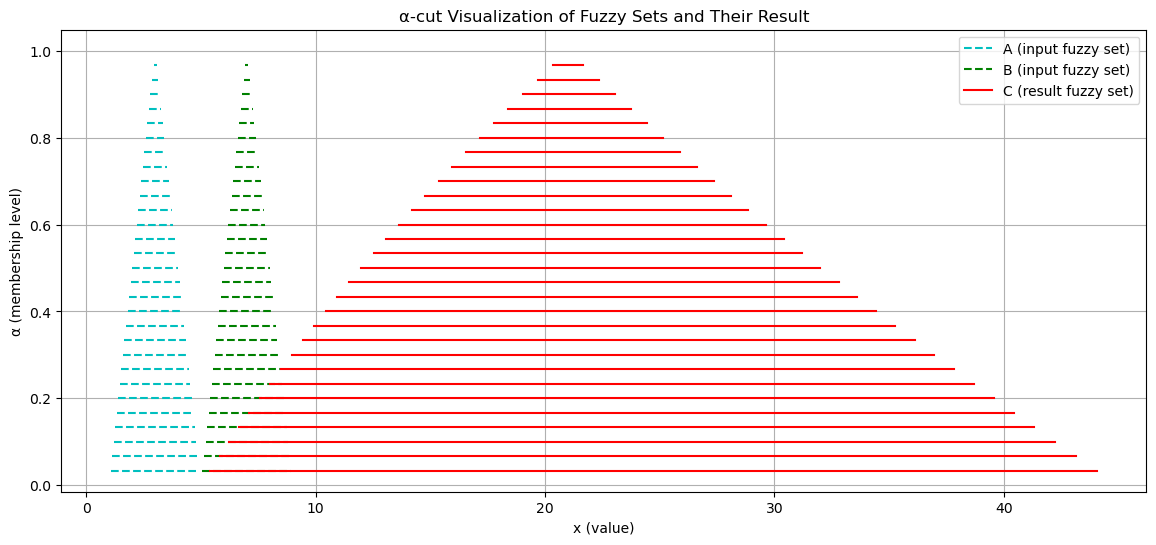

In [14]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm

# first input
# about 3
A = np.asarray( [1,3,5] )

# second input
# about 7
B = np.asarray( [5,7,9] )

# alpha cut parameters
NoSlices = 30  # We will use 30 α-cuts to approximate the fuzzy numbers

# Create an array like [1/30,2/30,3/30.....30/30]
#                      [0.0333, 0.0666, 0.1, 0.1333, ..., 1.0]
AlphaCuts = np.asarray( range(1,NoSlices+1) ).astype(float) / NoSlices

# A_α = [a, b]   B_α = [c, d] 
# define the function
def IntervalFunction( a, b, c, d, WhichOp ):
    if( WhichOp == 1 ): # sum
        return (a+c), (b+d)        
    elif( WhichOp == 2 ): # mul
        return min(a*c,a*d,b*c,b*d), max(a*c,a*d,b*c,b*d)     # need to consider ALL combinations, because the minimum product could come from ANY combination depending on sign. (Can be verified later)
    elif( WhichOp == 3 ): # minus
        return (a-d), (b-c)  
    elif( WhichOp == 4 ): # div
        return min(a/c, a/d, b/c, b/d), max(a/c, a/d, b/c, b/d) # check later
    
# get interval from a triangular membership function
# remember, the fuzzy set is defined as [left, center, right]
def GetTriInterval( fuzzyset, alphacut ):
    # memb == (x-a)/(b-a)
    #  alphacut = (x-fuzzyset[0]) / (fuzzyset[1]-fuzzyset[0])
    #  (fuzzyset[1]-fuzzyset[0]) * alphacut = x-fuzzyset[0]
    #  (fuzzyset[1]-fuzzyset[0]) * alphacut + fuzzyset[0] = x
    a = (fuzzyset[1]-fuzzyset[0]) * alphacut + fuzzyset[0]  # 这里是在x轴上偏移的距离，这个距离是由alphacut决定的。想象图
    # memb == (c-x)/(c-b)
    #  alphacut = (fuzzyset[2]-x) / (fuzzyset[2]-fuzzyset[1])
    #  (fuzzyset[2]-fuzzyset[1]) * alphacut = (fuzzyset[2]-x)
    #  fuzzyset[2] - (fuzzyset[2]-fuzzyset[1]) * alphacut = x    
    b = fuzzyset[2] - (fuzzyset[2]-fuzzyset[1]) * alphacut
    return a, b

# which operator do we want to use? 1 == sum, 2 == mul, 3 == minus, 4 = div
WhichOp = 2
    
fig = plt.figure(figsize=(14, 6))    
for i in range( AlphaCuts.size ):
    alpha = AlphaCuts[i]
    # get interval 1
    a, b = GetTriInterval( A, alpha )
    if i == 0:
        plt.plot([a,b], [alpha,alpha], '--c', label='A (input fuzzy set)')
    else:
        plt.plot([a,b], [alpha,alpha], '--c')  # Draw a cyan line horizontally in [a,b] and vertically in [alpha,alpha] (height)
    
    # get interval 2
    c, d = GetTriInterval( B, alpha )
    if i == 0:
        plt.plot([c,d], [alpha,alpha], '--g', label='B (input fuzzy set)')
    else:
        plt.plot([c,d], [alpha,alpha], '--g')    
    
    # calc result
    e, f = IntervalFunction( a, b, c, d, WhichOp )
    if i == 0:
        plt.plot([e,f], [alpha,alpha], 'r', label='C (result fuzzy set)')
    else:
        plt.plot([e,f], [alpha,alpha], 'r')

plt.legend()
plt.xlabel("x (value)")
plt.ylabel("α (membership level)")
plt.title("α-cut Visualization of Fuzzy Sets and Their Result")
plt.grid()
plt.show()